In [7]:
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import fasttext
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
import os

from datetime import datetime
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import Dataset, DataLoader

# ==============================================================================
# CONFIGURACION GENERAL
# ==============================================================================


# --- Rutas de entrada ---
FASTTEXT_PATH = r'C:\Users\AaronMCC\Documents\Rest-Mex2025\dataset\cc.es.300.bin'
DATA_PATH     = r'C:\Users\AaronMCC\Documents\Rest-Mex2025\dataset\rest_mex_cleaned_v2.pkl'

# --- Rutas de salida ---

now = datetime.now() # Obtener la fecha y hora actual
date_time = now.strftime("%d_%m_%Y_%H_%M_%S")

OUTPUT_DIR        = r'C:\Users\AaronMCC\Documents\Rest-Mex2025\resultados\res_' + date_time

os.mkdir(OUTPUT_DIR)

BEST_MODEL_PATH   = OUTPUT_DIR + r'\models\best_model_' + date_time + '.pt'
CSV_HISTORY       = OUTPUT_DIR + r'\training_history_' + date_time + '.csv'
CSV_OPTUNA        = OUTPUT_DIR + r'\optuna_results_' + date_time + '.csv'
PLOT_CURVES       = OUTPUT_DIR + r'\curvas_entrenamiento_' + date_time + '.png'
PLOT_CONFUSION    = OUTPUT_DIR + r'\confusion_matrix_' + date_time + '.png'

# --- Division del dataset ---
TRAIN_SIZE  = 0.70
VAL_SIZE    = 0.15
TEST_SIZE   = 0.15
RANDOM_SEED = 42

# --- Hiperparametros de entrenamiento ---
EPOCHS_OPTUNA = 15      # [CAMBIO] era 10
EPOCHS_FINAL  = 20
N_TRIALS      = 30
BATCH_SIZE    = 256
MAX_FEATURES  = 100_000
EMBED_DIM     = 300

# --- Nombres de clases ---
CLASS_NAMES = ['Muy negativo', 'Negativo', 'Neutral', 'Positivo', 'Muy positivo']

# ==============================================================================
# SEMILLA DE REPRODUCIBILIDAD
# [CAMBIO] Semilla fija completa: random, numpy, torch CPU y GPU
# ==============================================================================
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {device}")

# ==============================================================================
# 1. CARGA DE DATOS
# ==============================================================================
print("Cargando dataset...")
df = pd.read_pickle(DATA_PATH)
df['label'] = df['Polarity'].astype(int) - 1  # Rango 0-4
print(f"Total de ejemplos: {len(df):,}")

# ==============================================================================
# 2. DIVISION 70 / 15 / 15 ESTRATIFICADA
# ==============================================================================
train_df, temp_df = train_test_split(
    df,
    test_size=VAL_SIZE + TEST_SIZE,
    stratify=df['label'],
    random_state=RANDOM_SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=TEST_SIZE / (VAL_SIZE + TEST_SIZE),
    stratify=temp_df['label'],
    random_state=RANDOM_SEED
)

print(f"Train: {len(train_df):,} ({100*len(train_df)/len(df):.1f}%)")
print(f"Val:   {len(val_df):,} ({100*len(val_df)/len(df):.1f}%)")
print(f"Test:  {len(test_df):,} ({100*len(test_df)/len(df):.1f}%)")

# ==============================================================================
# 3. EMBEDDINGS FASTTEXT
# Vocabulario construido SOLO con train para evitar data leakage
# ==============================================================================
print("\nCargando modelo FastText...")
ft = fasttext.load_model(FASTTEXT_PATH)

def build_vocab_and_matrix(texts, ft_model, max_features=MAX_FEATURES):
    counts = Counter()
    for text in texts:
        counts.update(text.split())

    vocab = {word: i + 2 for i, (word, _) in enumerate(counts.most_common(max_features))}
    vocab['<PAD>'] = 0
    vocab['<OOV>'] = 1

    embedding_matrix = np.zeros((len(vocab), EMBED_DIM))
    for word, i in vocab.items():
        if i > 1:
            embedding_matrix[i] = ft_model.get_word_vector(word)
        elif i == 1:
            embedding_matrix[i] = np.random.normal(scale=0.6, size=(EMBED_DIM,))

    return vocab, torch.tensor(embedding_matrix, dtype=torch.float32)

vocab, embedding_matrix = build_vocab_and_matrix(train_df['text_combined'], ft)
del ft
print(f"Vocabulario (solo train): {len(vocab):,} tokens")

# ==============================================================================
# 4. TOKENIZACION Y DATASET
# MAX_LEN calculado SOLO sobre train para evitar data leakage
# ==============================================================================
MAX_LEN = int(train_df['text_combined'].str.split().str.len().quantile(0.95))
print(f"Longitud maxima de secuencia (p95 train): {MAX_LEN}")

def tokenize_text(text, vocab, max_len):
    tokens = [vocab.get(w, 1) for w in text.split()[:max_len]]
    return tokens + [0] * (max_len - len(tokens))

class RestMexDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len):
        self.sequences = [tokenize_text(t, vocab, max_len) for t in texts]
        self.labels    = labels.values

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.sequences[idx], dtype=torch.long),
            torch.tensor(self.labels[idx],    dtype=torch.long)
        )

train_ds = RestMexDataset(train_df['text_combined'], train_df['label'], vocab, MAX_LEN)
val_ds   = RestMexDataset(val_df['text_combined'],   val_df['label'],   vocab, MAX_LEN)
test_ds  = RestMexDataset(test_df['text_combined'],  test_df['label'],  vocab, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

# Class weights calculados SOLO sobre train
weights       = compute_class_weight('balanced', classes=np.unique(train_df['label']), y=train_df['label'])
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

# ==============================================================================
# 5. ARQUITECTURA Bi-LSTM
# [CAMBIO] spatial_dropout y lstm_dropout separados
# ==============================================================================
class SpatialDropout(nn.Dropout2d):
    def forward(self, x):
        x = x.unsqueeze(2)
        x = x.permute(0, 3, 2, 1)
        x = super().forward(x)
        x = x.permute(0, 3, 2, 1)
        x = x.squeeze(2)
        return x

class BiLSTMClassifier(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim, num_layers,
                 spatial_dropout, lstm_dropout, freeze=True):
        super().__init__()
        self.embedding       = nn.Embedding.from_pretrained(embedding_matrix, freeze=freeze)
        self.spatial_dropout = SpatialDropout(spatial_dropout)
        self.lstm            = nn.LSTM(
            EMBED_DIM, hidden_dim,
            num_layers    = num_layers,
            dropout       = lstm_dropout if num_layers > 1 else 0.0,
            bidirectional = True,
            batch_first   = True
        )
        self.fc = nn.Linear(hidden_dim * 2 * 2, 5)

    def forward(self, x):
        x = self.embedding(x)
        x = self.spatial_dropout(x)
        lstm_out, _ = self.lstm(x)
        avg_pool    = torch.mean(lstm_out, 1)
        max_pool, _ = torch.max(lstm_out, 1)
        combined    = torch.cat((avg_pool, max_pool), 1)
        return self.fc(combined)

# ==============================================================================
# 6. FUNCIONES DE ENTRENAMIENTO Y EVALUACION
# ==============================================================================
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for texts, labels in loader:
        texts, labels = texts.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(texts)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()
    return total_loss / len(loader), 100 * correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for texts, labels in loader:
            texts, labels = texts.to(device), labels.to(device)
            outputs = model(texts)
            loss    = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    accuracy = 100 * correct / total
    avg_f1   = f1_score(all_labels, all_preds, average='macro') * 100
    return avg_loss, accuracy, avg_f1, all_preds, all_labels

def compute_full_metrics(labels, preds):
    return {
        'macro_f1':        f1_score(labels, preds, average='macro') * 100,
        'accuracy':        accuracy_score(labels, preds) * 100,
        'macro_precision': precision_score(labels, preds, average='macro', zero_division=0) * 100,
        'macro_recall':    recall_score(labels, preds, average='macro', zero_division=0) * 100,
    }

def print_metrics(metrics, titulo):
    print(f"\n{titulo}")
    print(f"  Macro F1:        {metrics['macro_f1']:.2f}%")
    print(f"  Accuracy:        {metrics['accuracy']:.2f}%")
    print(f"  Macro Precision: {metrics['macro_precision']:.2f}%")
    print(f"  Macro Recall:    {metrics['macro_recall']:.2f}%")

def plot_confusion_matrix(labels, preds, titulo, save_path):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(titulo)
    plt.ylabel('Etiqueta real')
    plt.xlabel('Etiqueta predicha')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Matriz guardada en: {save_path}")

# ==============================================================================
# 7. FUNCION OBJETIVO DE OPTUNA
# [CAMBIO] spatial_dropout y lstm_dropout separados
# [CAMBIO] label_smoothing incluido en busqueda
# [CAMBIO] Sin ReduceLROnPlateau dentro de los trials
# [CAMBIO] EPOCHS_OPTUNA=15, patience=4
# ==============================================================================
def objective(trial):
    hidden_dim      = trial.suggest_categorical('hidden_dim', [64, 128, 256])
    num_layers      = trial.suggest_int('num_layers', 1, 2)
    spatial_dropout = trial.suggest_float('spatial_dropout', 0.1, 0.4)
    lstm_dropout    = trial.suggest_float('lstm_dropout', 0.1, 0.5)
    lr              = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    weight_decay    = trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True)
    freeze          = trial.suggest_categorical('freeze', [True, False])
    label_smoothing = trial.suggest_float('label_smoothing', 0.0, 0.2)

    model     = BiLSTMClassifier(
                    embedding_matrix,
                    hidden_dim,
                    num_layers,
                    spatial_dropout,
                    lstm_dropout,
                    freeze
                ).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=label_smoothing)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    # Sin scheduler dentro de Optuna: el ruido del F1 lo activaria prematuramente

    best_f1         = 0.0
    no_improve      = 0
    patience_optuna = 4     # [CAMBIO] era 3

    for epoch in range(1, EPOCHS_OPTUNA + 1):
        train_epoch(model, train_loader, optimizer, criterion)
        _, _, v_f1, _, _ = evaluate(model, val_loader, criterion)

        if v_f1 > best_f1:
            best_f1    = v_f1
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience_optuna:
                break

    return best_f1

# ==============================================================================
# 8. EJECUTAR OPTUNA
# ==============================================================================
print(f"\nIniciando busqueda de hiperparametros ({N_TRIALS} trials)...")
optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(direction='maximize')

# [CAMBIO] Trial encolado actualizado: lr mas conservador, dropouts separados,
# label_smoothing incluido
study.enqueue_trial({
    'hidden_dim':      128,
    'num_layers':      2,
    'spatial_dropout': 0.2,
    'lstm_dropout':    0.25,
    'lr':              0.001,
    'weight_decay':    2.3e-05,
    'freeze':          True,
    'label_smoothing': 0.1
})

study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nMejor V-F1 (Optuna):  {study.best_value:.2f}%")
print("Mejores hiperparametros:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

optuna_df = study.trials_dataframe()
optuna_df.to_csv(CSV_OPTUNA, index=False)
print(f"Resultados Optuna guardados en: {CSV_OPTUNA}")



C:\Users\AaronMCC\miniconda3\envs\clas_Rest-Mex2025\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dispositivo: cuda
Cargando dataset...
Total de ejemplos: 207,688
Train: 145,381 (70.0%)
Val:   31,153 (15.0%)
Test:  31,154 (15.0%)

Cargando modelo FastText...
Vocabulario (solo train): 100,002 tokens
Longitud maxima de secuencia (p95 train): 146

Iniciando busqueda de hiperparametros (30 trials)...


Best trial: 13. Best value: 57.009: 100%|█████████████████████████████████| 30/30 [1:50:51<00:00, 221.72s/it]



Mejor V-F1 (Optuna):  57.01%
Mejores hiperparametros:
  hidden_dim: 128
  num_layers: 2
  spatial_dropout: 0.27263973845165085
  lstm_dropout: 0.27250710357694474
  lr: 0.0020204623717309253
  weight_decay: 9.223502390616694e-05
  freeze: True
  label_smoothing: 0.005575858960362418
Resultados Optuna guardados en: C:\Users\AaronMCC\Documents\Rest-Mex2025\resultados\res_14_03_2026_15_44_30\optuna_results_14_03_2026_15_44_30.csv

Entrenamiento final con mejores hiperparametros (20 epocas)...
Epoca |  T-Loss |   T-Acc |  V-Loss |   V-Acc |    V-F1 |         LR
---------------------------------------------------------------------------
    1 |   1.303 |  51.56% |   1.110 |  64.47% |  46.82% | LR: 2.02e-03


RuntimeError: Parent directory C:\Users\AaronMCC\Documents\Rest-Mex2025\resultados\res_14_03_2026_15_44_30\models does not exist.


Entrenamiento final con mejores hiperparametros (20 epocas)...
Epoca |  T-Loss |   T-Acc |  V-Loss |   V-Acc |    V-F1 |         LR
---------------------------------------------------------------------------
    1 |   1.297 |  52.50% |   1.134 |  52.68% |  45.39% | LR: 2.02e-03
    2 |   1.128 |  60.55% |   1.058 |  65.51% |  50.23% | LR: 2.02e-03
    3 |   1.074 |  63.13% |   1.043 |  66.49% |  52.98% | LR: 2.02e-03
    4 |   1.054 |  64.00% |   1.033 |  65.07% |  48.19% | LR: 2.02e-03
    5 |   1.039 |  64.47% |   1.045 |  68.85% |  55.72% | LR: 2.02e-03
    6 |   1.031 |  64.77% |   1.013 |  68.49% |  54.18% | LR: 2.02e-03
    7 |   1.020 |  65.08% |   1.013 |  70.72% |  54.89% | LR: 2.02e-03
    8 |   1.015 |  65.47% |   0.993 |  65.14% |  52.40% | LR: 1.01e-03
    9 |   0.989 |  66.19% |   0.982 |  69.12% |  56.60% | LR: 1.01e-03
   10 |   0.985 |  66.35% |   0.990 |  62.85% |  52.15% | LR: 1.01e-03
   11 |   0.983 |  66.35% |   0.977 |  68.97% |  55.48% | LR: 1.01e-03
   12 |   

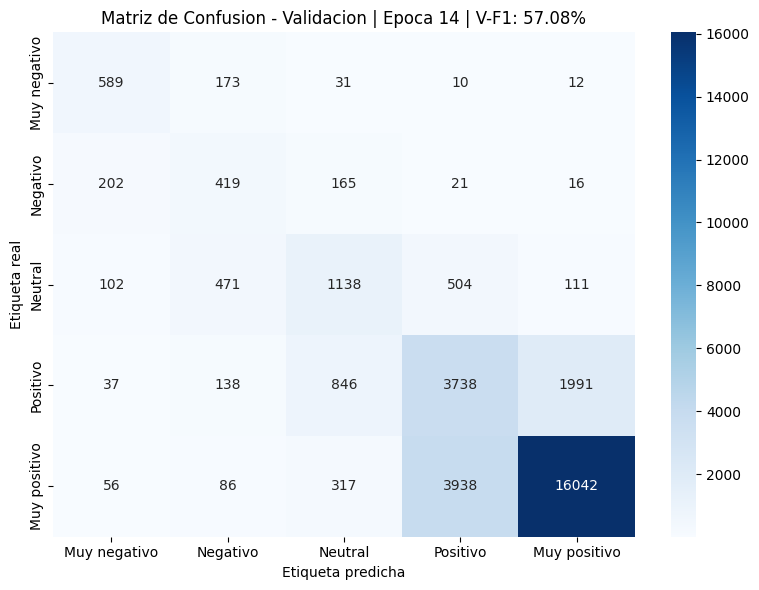

Matriz guardada en: C:\Users\AaronMCC\Documents\Rest-Mex2025\resultados\res_14_03_2026_15_44_30\confusion_matrix_14_03_2026_15_44_30.png

Cargando mejor modelo para evaluacion en test interno...

Metricas Finales sobre Test Interno
  Macro F1:        56.39%
  Accuracy:        70.11%
  Macro Precision: 53.81%
  Macro Recall:    60.25%

Reporte de Clasificacion - Test Interno
              precision    recall  f1-score   support

Muy negativo       0.58      0.69      0.63       815
    Negativo       0.32      0.50      0.39       823
     Neutral       0.46      0.49      0.48      2326
    Positivo       0.45      0.54      0.49      6751
Muy positivo       0.88      0.79      0.83     20439

    accuracy                           0.70     31154
   macro avg       0.54      0.60      0.56     31154
weighted avg       0.73      0.70      0.71     31154



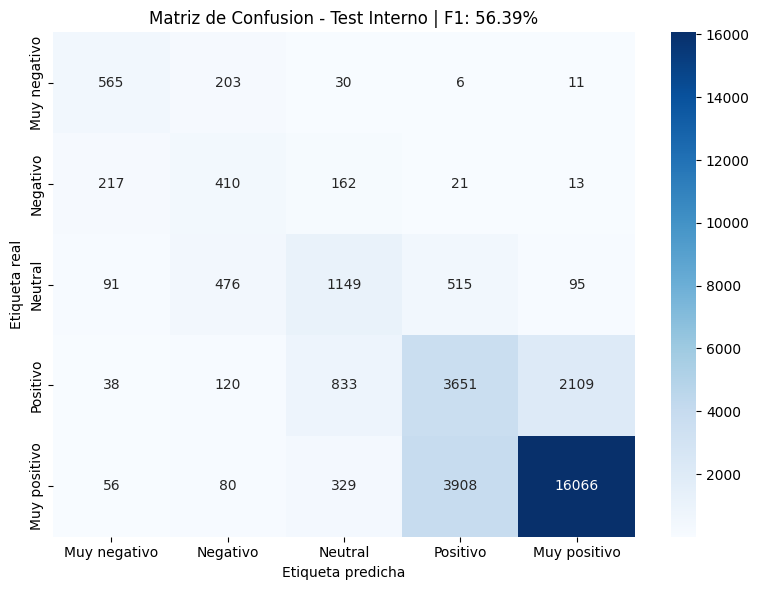

Matriz guardada en: C:\Users\AaronMCC\Documents\Rest-Mex2025\resultados\res_14_03_2026_15_44_30\confusion_matrix_14_03_2026_15_44_30_test.png


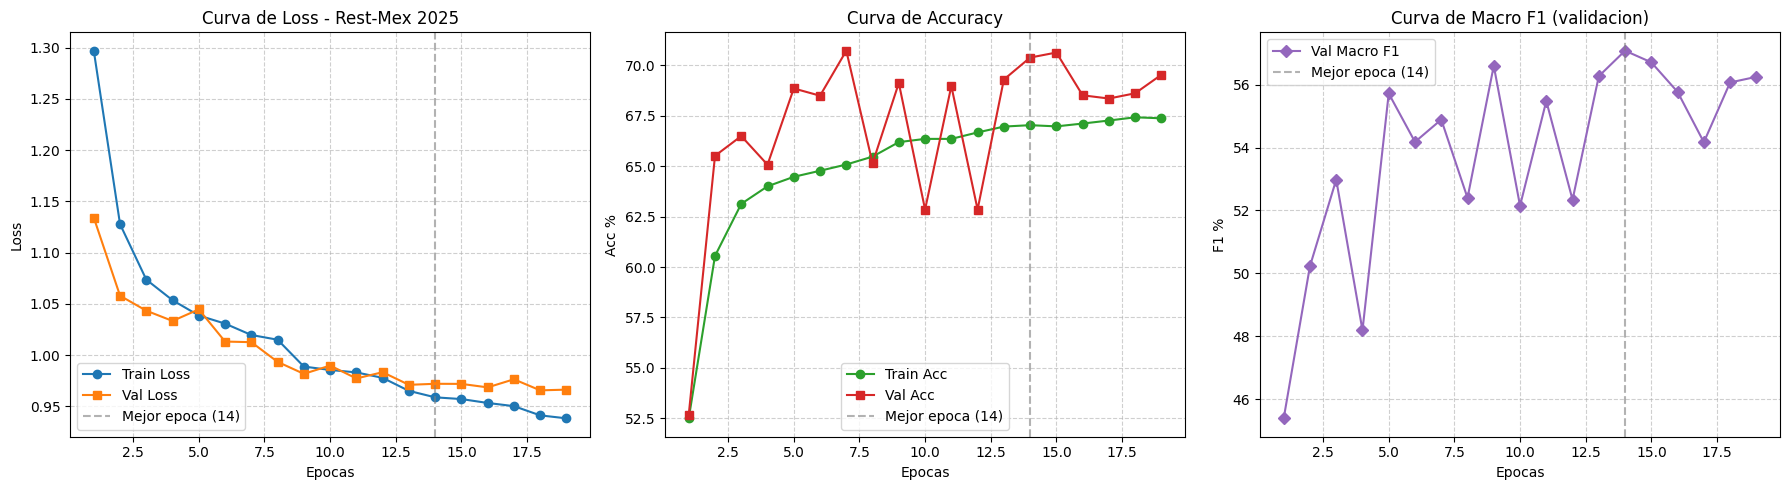

Graficas guardadas en: C:\Users\AaronMCC\Documents\Rest-Mex2025\resultados\res_14_03_2026_15_44_30\curvas_entrenamiento_14_03_2026_15_44_30.png


In [8]:
# ==============================================================================
# 9. ENTRENAMIENTO FINAL CON LOS MEJORES HIPERPARAMETROS
# [CAMBIO] ReduceLROnPlateau solo aqui, no en Optuna
# [CAMBIO] criterion usa label_smoothing del mejor trial
# ==============================================================================

BEST_MODEL_PATH   = r'C:\Users\AaronMCC\Documents\Rest-Mex2025\models\best_model_' + date_time + '.pt'

best = study.best_params

print(f"\nEntrenamiento final con mejores hiperparametros ({EPOCHS_FINAL} epocas)...")

model_final = BiLSTMClassifier(
    embedding_matrix,
    hidden_dim      = best['hidden_dim'],
    num_layers      = best['num_layers'],
    spatial_dropout = best['spatial_dropout'],
    lstm_dropout    = best['lstm_dropout'],
    freeze          = best['freeze']
).to(device)

criterion_final = nn.CrossEntropyLoss(
    weight          = class_weights,
    label_smoothing = best['label_smoothing']
)
optimizer_final = optim.Adam(
    model_final.parameters(),
    lr           = best['lr'],
    weight_decay = best['weight_decay']
)
scheduler_final = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_final, mode='max', factor=0.5, patience=2
)

history = {
    'epoch':      [],
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   [], 'val_f1': [],
    'lr':         []
}

best_val_f1 = 0.0
best_epoch  = 0
best_preds  = []
best_labels = []
no_improve  = 0
patience    = 5

print(f"{'Epoca':>5} | {'T-Loss':>7} | {'T-Acc':>7} | {'V-Loss':>7} | {'V-Acc':>7} | {'V-F1':>7} | {'LR':>10}")
print("-" * 75)

for epoch in range(1, EPOCHS_FINAL + 1):
    t_loss, t_acc                        = train_epoch(model_final, train_loader, optimizer_final, criterion_final)
    v_loss, v_acc, v_f1, v_preds, v_lbls = evaluate(model_final, val_loader, criterion_final)

    scheduler_final.step(v_f1)
    current_lr = optimizer_final.param_groups[0]['lr']

    history['epoch'].append(epoch)
    history['train_loss'].append(round(t_loss, 4))
    history['train_acc'].append(round(t_acc, 2))
    history['val_loss'].append(round(v_loss, 4))
    history['val_acc'].append(round(v_acc, 2))
    history['val_f1'].append(round(v_f1, 2))
    history['lr'].append(current_lr)

    print(f"{epoch:>5} | {t_loss:>7.3f} | {t_acc:>6.2f}% | {v_loss:>7.3f} | {v_acc:>6.2f}% | {v_f1:>6.2f}% | LR: {current_lr:.2e}")

    if v_f1 > best_val_f1:
        best_val_f1 = v_f1
        best_epoch  = epoch
        best_preds  = v_preds
        best_labels = v_lbls
        no_improve  = 0
        torch.save(model_final.state_dict(), BEST_MODEL_PATH)
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"Early stopping en epoca {epoch} | Mejor V-F1: {best_val_f1:.2f}%")
            break

# ==============================================================================
# 10. GUARDAR HISTORIAL EN CSV
# ==============================================================================
history_df = pd.DataFrame(history)
history_df.to_csv(CSV_HISTORY, index=False)
print(f"\nHistorial guardado en: {CSV_HISTORY}")

# ==============================================================================
# 11. METRICAS Y REPORTE SOBRE VALIDACION (mejor epoca)
# ==============================================================================
val_metrics = compute_full_metrics(best_labels, best_preds)
print_metrics(val_metrics, f"Metricas de Validacion (Epoca {best_epoch})")
print(f"\nReporte de Clasificacion - Validacion (Epoca {best_epoch})")
print(classification_report(best_labels, best_preds, target_names=CLASS_NAMES))
plot_confusion_matrix(
    best_labels, best_preds,
    titulo    = f'Matriz de Confusion - Validacion | Epoca {best_epoch} | V-F1: {best_val_f1:.2f}%',
    save_path = PLOT_CONFUSION
)

# ==============================================================================
# 12. EVALUACION FINAL SOBRE TEST INTERNO
# ==============================================================================
print("\nCargando mejor modelo para evaluacion en test interno...")
model_final.load_state_dict(torch.load(BEST_MODEL_PATH))

_, _, test_f1, test_preds, test_labels = evaluate(model_final, test_loader, criterion_final)
test_metrics = compute_full_metrics(test_labels, test_preds)

print_metrics(test_metrics, "Metricas Finales sobre Test Interno")
print(f"\nReporte de Clasificacion - Test Interno")
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES))
plot_confusion_matrix(
    test_labels, test_preds,
    titulo    = f'Matriz de Confusion - Test Interno | F1: {test_metrics["macro_f1"]:.2f}%',
    save_path = PLOT_CONFUSION.replace('.png', '_test.png')
)

# ==============================================================================
# 13. GRAFICAS DE ENTRENAMIENTO
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['epoch'], history['train_loss'], label='Train Loss', color='#1f77b4', marker='o')
axes[0].plot(history['epoch'], history['val_loss'],   label='Val Loss',   color='#ff7f0e', marker='s')
axes[0].axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.6, label=f'Mejor epoca ({best_epoch})')
axes[0].set_title('Curva de Loss - Rest-Mex 2025')
axes[0].set_xlabel('Epocas')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot(history['epoch'], history['train_acc'], label='Train Acc', color='#2ca02c', marker='o')
axes[1].plot(history['epoch'], history['val_acc'],   label='Val Acc',   color='#d62728', marker='s')
axes[1].axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.6, label=f'Mejor epoca ({best_epoch})')
axes[1].set_title('Curva de Accuracy')
axes[1].set_xlabel('Epocas')
axes[1].set_ylabel('Acc %')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

axes[2].plot(history['epoch'], history['val_f1'], label='Val Macro F1', color='#9467bd', marker='D')
axes[2].axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.6, label=f'Mejor epoca ({best_epoch})')
axes[2].set_title('Curva de Macro F1 (validacion)')
axes[2].set_xlabel('Epocas')
axes[2].set_ylabel('F1 %')
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig(PLOT_CURVES, dpi=150)
plt.show()
print(f"Graficas guardadas en: {PLOT_CURVES}")